# Prediksi Status Gizi Balita Menggunakan K-Nearest Neighbor (KNN)

Model melakukan klasifikasi multikelas (`normal`, `stunted`, `severely stunted`, dan `tinggi`) berdasarkan umur, jenis kelamin, dan tinggi badan.

Tahapan: Data Collection → EDA → Data Processing → Feature Engineering → Modelling KNN → Evaluation → Simpan Model → Inference.

> Model ini ditujukan untuk pembelajaran/penelitian dan tidak menggantikan pemeriksaan tenaga kesehatan atau standar antropometri resmi.

## Persiapan Environment

In [ ]:
import json, time, inspect, warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_TUNING_SAMPLES = 10_000
K_CANDIDATES = [3, 5, 7, 9, 11, 15, 21]
OUTPUT_DIR = Path('/content/output_model_knn_balita')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', None)
print('Environment siap.')

# 1. Data Collection
Notebook mencari `data_balita(1).csv` atau `data_balita.csv` di `/content`. Jika tidak ditemukan, dialog upload Colab akan muncul.

In [ ]:
CANDIDATE_PATHS = [Path('/content/data_balita(1).csv'), Path('/content/data_balita.csv'),
                   Path('data_balita(1).csv'), Path('data_balita.csv')]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError('Tidak ada file yang di-upload.')
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except ImportError as exc:
        raise FileNotFoundError('Letakkan data_balita(1).csv pada folder kerja.') from exc

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset: {DATA_PATH}')
print(f'Ukuran awal: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
display(df_raw.head())

# 2. Exploratory Data Analysis (EDA)
EDA memeriksa struktur, missing value, duplikasi, distribusi kelas, dan pola umur–tinggi badan.

In [ ]:
EXPECTED_COLUMNS = ['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)', 'Status Gizi']
missing = [c for c in EXPECTED_COLUMNS if c not in df_raw.columns]
if missing:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing}')

quality = pd.DataFrame({
    'Tipe Data': df_raw.dtypes.astype(str),
    'Missing': df_raw.isna().sum(),
    'Missing (%)': (df_raw.isna().mean()*100).round(2),
    'Nilai Unik': df_raw.nunique(dropna=False)
})
display(df_raw.describe(include='all').T)
display(quality)
print(f'Duplikasi identik: {df_raw.duplicated().sum():,}')

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Umur (bulan),120999.0,NaN,NaN,NaN,30.173803,17.575119,0.0,15.0,30.0,45.0,60.0
Jenis Kelamin,120999,2,perempuan,61002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tinggi Badan (cm),120999.0,NaN,NaN,NaN,88.655434,17.300997,40.010437,77.0,89.8,101.2,128.0
Status Gizi,120999,4,normal,67755,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Tipe Data,Missing,Missing (%),Nilai Unik
Umur (bulan),int64,0,0.0,61
Jenis Kelamin,object,0,0.0,2
Tinggi Badan (cm),float64,0,0.0,6800
Status Gizi,object,0,0.0,4


Duplikasi identik: 81,574


,Jumlah,Persentase (%)
Status Gizi,,
normal,67755,56.00
severely stunted,19869,16.42
tinggi,19560,16.17
stunted,13815,11.42


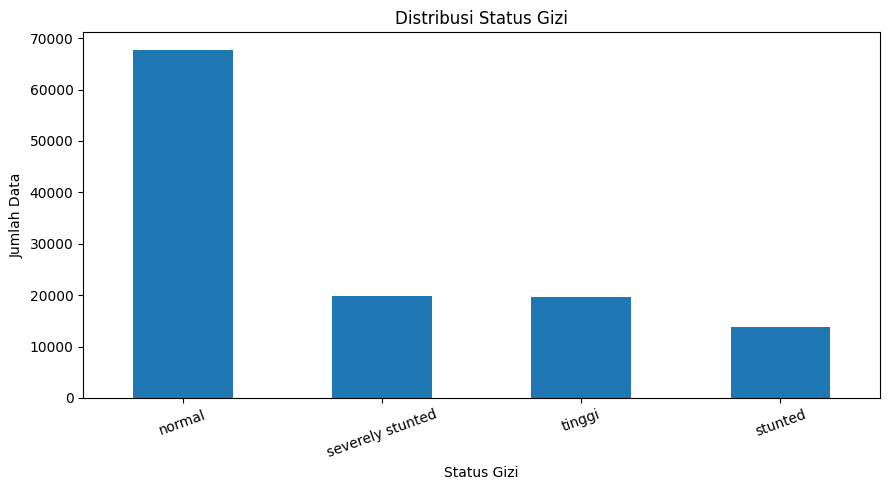

In [ ]:
target_counts = df_raw['Status Gizi'].astype(str).str.strip().str.lower().value_counts()
display(pd.DataFrame({'Jumlah': target_counts,
                      'Persentase (%)': (target_counts/target_counts.sum()*100).round(2)}))
plt.figure(figsize=(9,5))
target_counts.plot(kind='bar')
plt.title('Distribusi Status Gizi')
plt.xlabel('Status Gizi'); plt.ylabel('Jumlah Data')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

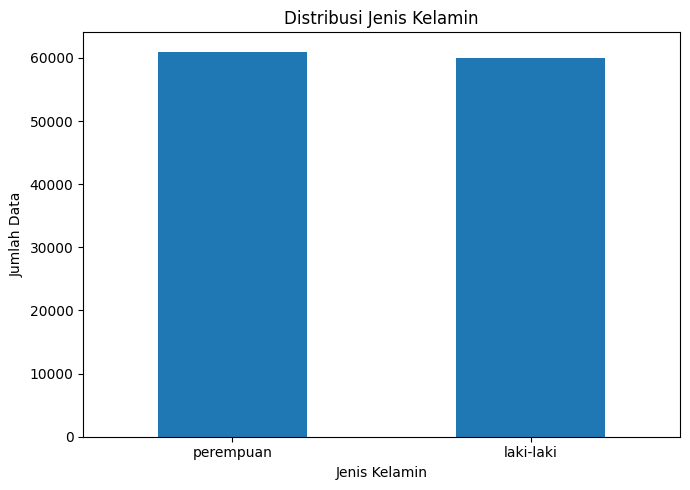

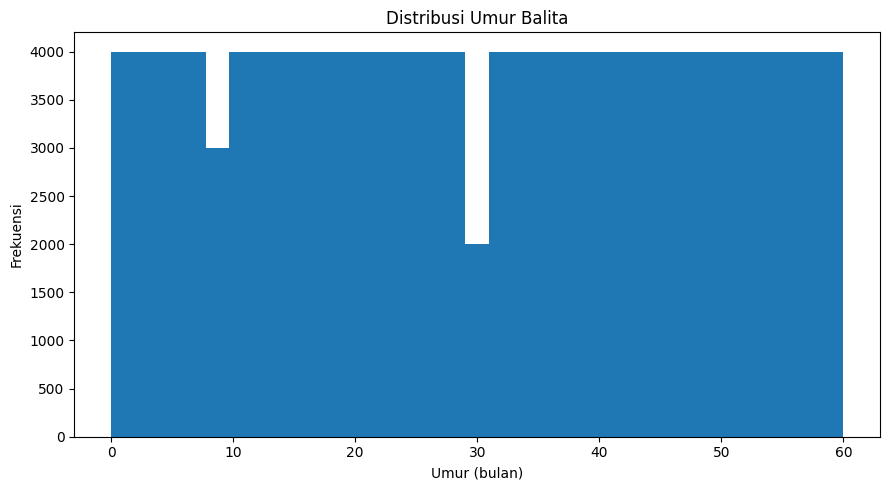

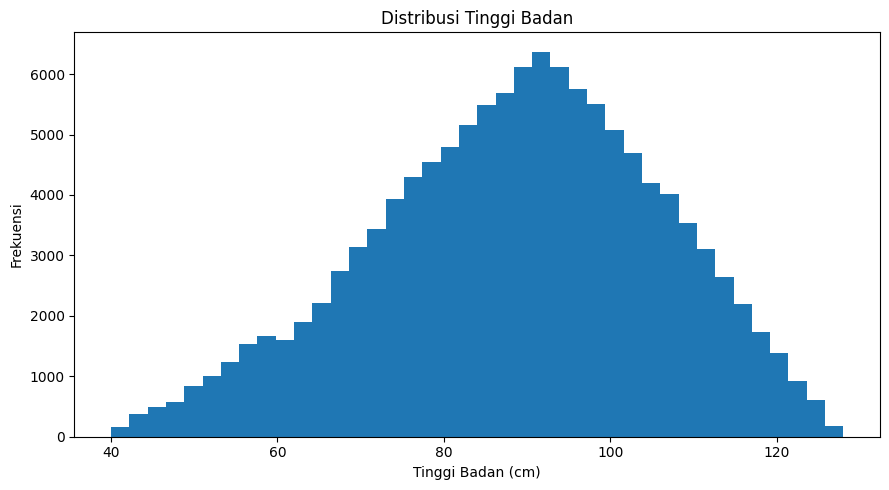

In [ ]:
gender_counts = df_raw['Jenis Kelamin'].value_counts()
plt.figure(figsize=(7,5))
gender_counts.plot(kind='bar')
plt.title('Distribusi Jenis Kelamin')
plt.xlabel('Jenis Kelamin'); plt.ylabel('Jumlah Data')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
plt.hist(df_raw['Umur (bulan)'].dropna(), bins=31)
plt.title('Distribusi Umur Balita')
plt.xlabel('Umur (bulan)'); plt.ylabel('Frekuensi')
plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
plt.hist(df_raw['Tinggi Badan (cm)'].dropna(), bins=40)
plt.title('Distribusi Tinggi Badan')
plt.xlabel('Tinggi Badan (cm)'); plt.ylabel('Frekuensi')
plt.tight_layout(); plt.show()

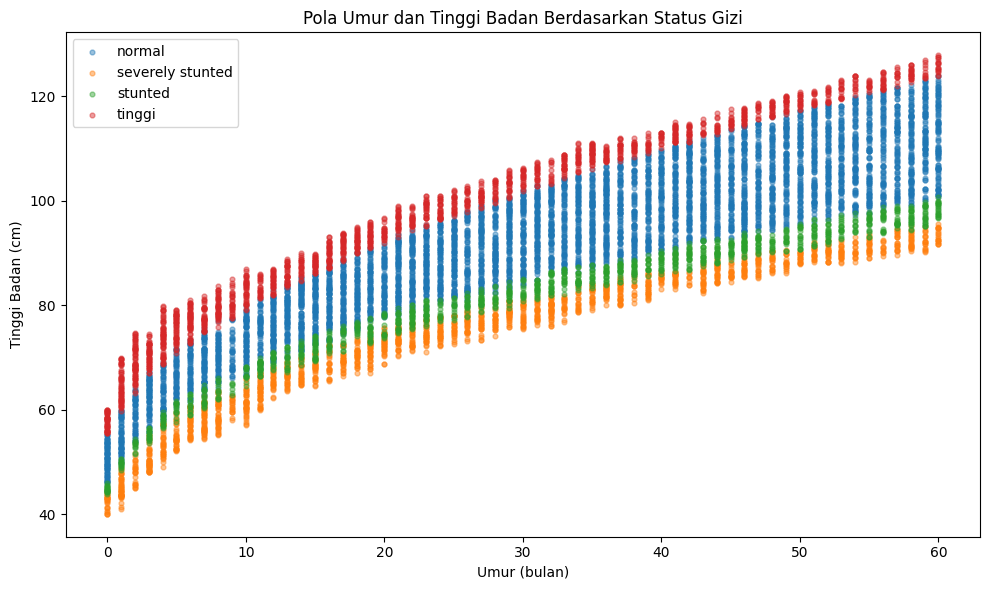

In [ ]:
eda_sample = df_raw.sample(n=min(10_000, len(df_raw)), random_state=RANDOM_STATE)
plt.figure(figsize=(10,6))
for class_name, group in eda_sample.groupby('Status Gizi'):
    plt.scatter(group['Umur (bulan)'], group['Tinggi Badan (cm)'],
                alpha=0.45, s=12, label=class_name)
plt.title('Pola Umur dan Tinggi Badan Berdasarkan Status Gizi')
plt.xlabel('Umur (bulan)'); plt.ylabel('Tinggi Badan (cm)')
plt.legend(); plt.tight_layout(); plt.show()

# 3. Data Processing
Tahap ini merapikan kategori, mengubah fitur numerik, memvalidasi rentang, menghapus target tidak valid, memeriksa konflik label, dan menghapus duplikasi identik untuk mengurangi data leakage. Missing value fitur ditangani di dalam pipeline.

In [ ]:
RAW_FEATURES = ['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)']
TARGET = 'Status Gizi'
VALID_GENDERS = {'laki-laki', 'perempuan'}
VALID_TARGETS = {'normal', 'stunted', 'severely stunted', 'tinggi'}
VALID_AGE_RANGE = (0, 60)
VALID_HEIGHT_RANGE = (30.0, 150.0)

df_clean = df_raw[RAW_FEATURES + [TARGET]].copy()
for c in ['Jenis Kelamin', TARGET]:
    df_clean[c] = (df_clean[c].astype('string').str.strip().str.lower()
                   .str.replace(r'\s+', ' ', regex=True))
for c in ['Umur (bulan)', 'Tinggi Badan (cm)']:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

df_clean.loc[~df_clean['Umur (bulan)'].between(*VALID_AGE_RANGE), 'Umur (bulan)'] = np.nan
df_clean.loc[~df_clean['Tinggi Badan (cm)'].between(*VALID_HEIGHT_RANGE), 'Tinggi Badan (cm)'] = np.nan
df_clean.loc[~df_clean['Jenis Kelamin'].isin(VALID_GENDERS), 'Jenis Kelamin'] = pd.NA

before_target = len(df_clean)
df_clean = df_clean[df_clean[TARGET].isin(VALID_TARGETS)].copy()
invalid_target_removed = before_target - len(df_clean)
conflicts = int((df_clean.groupby(RAW_FEATURES, dropna=False)[TARGET].nunique() > 1).sum())
duplicates = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

display(pd.DataFrame({
    'Keterangan': ['Data awal','Target tidak valid dihapus','Duplikasi dihapus',
                   'Kelompok label konflik','Data setelah processing'],
    'Nilai': [len(df_raw), invalid_target_removed, duplicates, conflicts, len(df_clean)]
}))
display(df_clean.isna().sum().to_frame('Missing'))
display(df_clean[TARGET].value_counts().to_frame('Jumlah'))

,Keterangan,Nilai
0,Data awal,120999
1,Target tidak valid dihapus,0
2,Duplikasi dihapus,81574
3,Kelompok label konflik,0
4,Data setelah processing,39425


,Missing
Umur (bulan),0
Jenis Kelamin,0
Tinggi Badan (cm),0
Status Gizi,0


,Jumlah
Status Gizi,
normal,21514
tinggi,6974
severely stunted,6520
stunted,4417


# 4. Feature Engineering
model tetap menggunakan tiga fitur asli. Umur dan tinggi badan diimputasi lalu dinormalisasi dengan `StandardScaler`; jenis kelamin diimputasi dan diubah dengan `OneHotEncoder`. Seluruh transformasi berada dalam pipeline agar tidak terjadi data leakage.

In [ ]:
X = df_clean[RAW_FEATURES].copy()
y = df_clean[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

numeric_features = ['Umur (bulan)', 'Tinggi Badan (cm)']
categorical_features = ['Jenis Kelamin']
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ohe_args = {'handle_unknown': 'ignore'}
if 'sparse_output' in inspect.signature(OneHotEncoder).parameters:
    ohe_args['sparse_output'] = False
else:
    ohe_args['sparse'] = False
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(**ohe_args))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
display(pd.DataFrame({'Train': y_train.value_counts(normalize=True),
                      'Test': y_test.value_counts(normalize=True)}).fillna(0).round(4))

Train: 31,540 | Test: 7,885


,Train,Test
Status Gizi,,
normal,0.5457,0.5457
tinggi,0.1769,0.1769
severely stunted,0.1654,0.1654
stunted,0.112,0.112


In [ ]:
preview_preprocessor = preprocessor.fit(X_train)
preview = preview_preprocessor.transform(X_train.head())
feature_names = preview_preprocessor.get_feature_names_out()
display(pd.DataFrame(preview, columns=feature_names, index=X_train.head().index))

,numeric__Umur (bulan),numeric__Tinggi Badan (cm),categorical__Jenis Kelamin_laki-laki,categorical__Jenis Kelamin_perempuan
26727,0.662405,0.219334,1.0,0.0
24481,0.454591,-0.231430,1.0,0.0
36517,1.441709,0.695422,0.0,1.0
9595,-0.948157,-0.996210,1.0,0.0
15512,-0.376667,0.092715,0.0,1.0


# 5. Modelling KNN
KNN menggunakan Euclidean distance dan majority voting. Nilai K terbaik dipilih dari 3, 5, 7, 9, 11, 15, dan 21 berdasarkan F1-Score macro pada validation subset. Pencarian K memakai sampel stratified agar praktis di Colab; model final tetap dilatih pada seluruh training set.

In [ ]:
def build_knn_pipeline(k):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='uniform',
                                    algorithm='kd_tree', leaf_size=40,
                                    metric='minkowski', p=2, n_jobs=-1))
    ])

if len(X_train) > MAX_TUNING_SAMPLES:
    X_tuning, _, y_tuning, _ = train_test_split(
        X_train, y_train, train_size=MAX_TUNING_SAMPLES,
        random_state=RANDOM_STATE, stratify=y_train)
else:
    X_tuning, y_tuning = X_train.copy(), y_train.copy()
X_fit, X_val, y_fit, y_val = train_test_split(
    X_tuning, y_tuning, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_tuning)
print(f'Tuning: {len(X_tuning):,} | Fit: {len(X_fit):,} | Validation: {len(X_val):,}')

Tuning: 10,000 | Fit: 8,000 | Validation: 2,000


In [ ]:
results = []
start_total = time.time()
for k in K_CANDIDATES:
    model = build_knn_pipeline(k)
    start = time.time()
    model.fit(X_fit, y_fit)
    pred = model.predict(X_val)
    results.append({
        'K': k,
        'Accuracy': accuracy_score(y_val, pred),
        'Precision Macro': precision_score(y_val, pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_val, pred, average='macro', zero_division=0),
        'F1-Score Macro': f1_score(y_val, pred, average='macro', zero_division=0),
        'Waktu (detik)': time.time()-start
    })

tuning_results = (pd.DataFrame(results)
                  .sort_values(['F1-Score Macro','Accuracy','K'],
                               ascending=[False,False,True]).reset_index(drop=True))
BEST_K = int(tuning_results.iloc[0]['K'])
print(f'K terbaik: {BEST_K} | Total tuning: {time.time()-start_total:.2f} detik')
display(tuning_results)

K terbaik: 3 | Total tuning: 0.74 detik


,K,Accuracy,Precision Macro,Recall Macro,F1-Score Macro,Waktu (detik)
0,3,0.9745,0.959956,0.965999,0.962945,0.106895
1,15,0.9715,0.958668,0.957761,0.958038,0.102403
2,5,0.9690,0.954453,0.955496,0.954950,0.094846
3,11,0.9680,0.952987,0.953148,0.952971,0.102542
4,7,0.9680,0.950858,0.954395,0.952599,0.106694
5,21,0.9665,0.954678,0.950442,0.952269,0.105579
6,9,0.9670,0.952115,0.952328,0.952126,0.113139


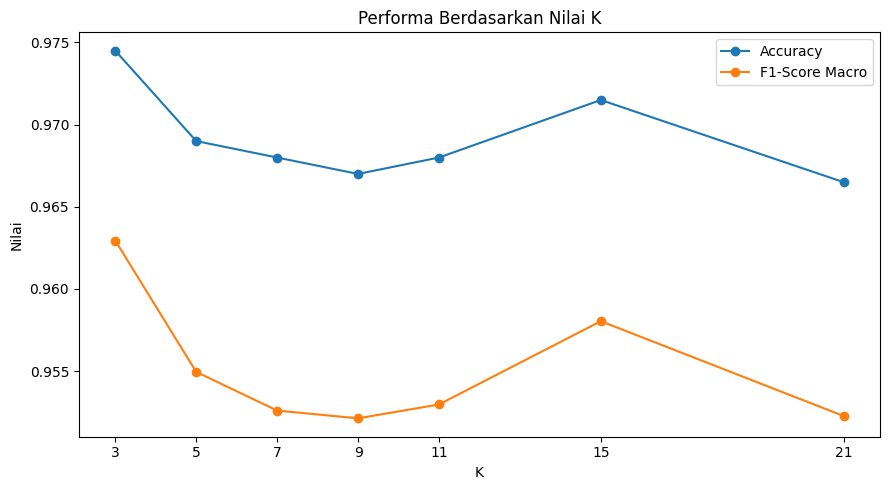

Model final dilatih pada 31,540 data. Waktu fit: 0.15 detik


In [ ]:
plot_df = tuning_results.sort_values('K')
plt.figure(figsize=(9,5))
plt.plot(plot_df['K'], plot_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(plot_df['K'], plot_df['F1-Score Macro'], marker='o', label='F1-Score Macro')
plt.title('Performa Berdasarkan Nilai K'); plt.xlabel('K'); plt.ylabel('Nilai')
plt.xticks(K_CANDIDATES); plt.legend(); plt.tight_layout(); plt.show()

final_model = build_knn_pipeline(BEST_K)
start = time.time()
final_model.fit(X_train, y_train)
print(f'Model final dilatih pada {len(X_train):,} data. Waktu fit: {time.time()-start:.2f} detik')

# 6. Evaluation
Evaluasi menggunakan test set terpisah dan metrik pada proposal: Accuracy, Precision, Recall, F1-Score, serta Confusion Matrix.

In [ ]:
start = time.time()
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)
prediction_time = time.time()-start
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision Macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
    'Recall Macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'F1-Score Macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'F1-Score Weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0)
}
print(f'K final: {BEST_K} | Waktu prediksi: {prediction_time:.2f} detik')
display(pd.DataFrame({'Metrik': metrics.keys(), 'Nilai': metrics.values()}))
display(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True,
                                           zero_division=0)).T)

K final: 3 | Waktu prediksi: 0.16 detik


,Metrik,Nilai
0,Accuracy,0.991630
1,Precision Macro,0.988151
2,Recall Macro,0.988326
3,F1-Score Macro,0.988238
4,F1-Score Weighted,0.991628


,precision,recall,f1-score,support
normal,0.995349,0.994655,0.995002,4303.00000
severely stunted,0.990805,0.991564,0.991184,1304.00000
stunted,0.975028,0.972820,0.973923,883.00000
tinggi,0.991422,0.994265,0.992842,1395.00000
accuracy,0.991630,0.991630,0.991630,0.99163
macro avg,0.988151,0.988326,0.988238,7885.00000
weighted avg,0.991627,0.991630,0.991628,7885.00000


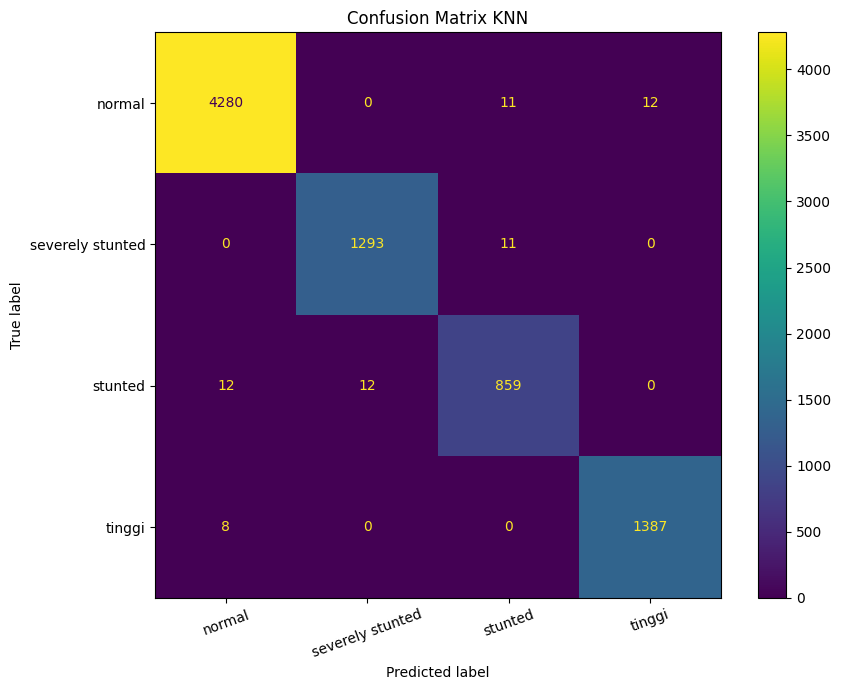

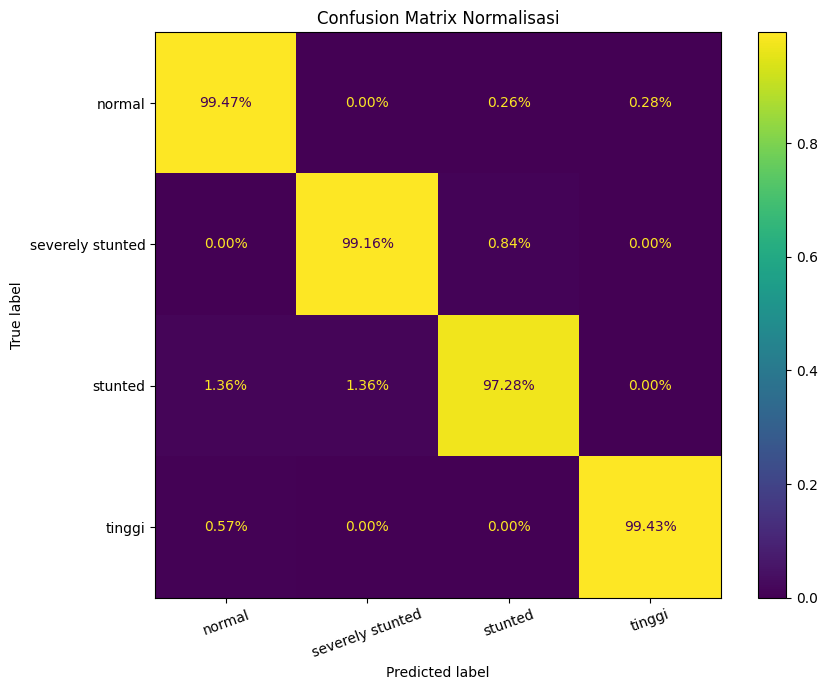

In [ ]:
classes = final_model.named_steps['knn'].classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, values_format='d')
plt.title('Confusion Matrix KNN'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

cm_norm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay(cm_norm, display_labels=classes).plot(ax=ax, values_format='.2%')
plt.title('Confusion Matrix Normalisasi'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

In [ ]:
errors = X_test.copy()
errors['Status Aktual'] = y_test
errors['Status Prediksi'] = y_pred
errors['Confidence'] = y_proba.max(axis=1)
errors = errors[errors['Status Aktual'] != errors['Status Prediksi']]
print(f'Prediksi benar: {(y_test.to_numpy()==y_pred).sum():,}')
print(f'Prediksi salah: {len(errors):,}')
display(errors.sort_values('Confidence', ascending=False).head(20))

Prediksi benar: 7,819
Prediksi salah: 66


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Aktual,Status Prediksi,Confidence
30935,48.0,laki-laki,116.0,tinggi,normal,1.000000
10760,12.0,perempuan,68.9,stunted,normal,0.666667
23915,36.0,perempuan,106.5,normal,tinggi,0.666667
34583,53.0,perempuan,119.1,normal,tinggi,0.666667
25532,39.0,laki-laki,86.4,severely stunted,stunted,0.666667
17969,26.0,laki-laki,82.5,stunted,normal,0.666667
26323,40.0,perempuan,109.7,normal,tinggi,0.666667
6445,3.0,perempuan,55.6,stunted,normal,0.666667
6927,4.0,perempuan,55.5,severely stunted,stunted,0.666667
18129,26.0,perempuan,80.9,normal,stunted,0.666667


# 6b. Model Pembanding: Random Forest

Sebagai pembanding KNN, digunakan **Random Forest Classifier**. Alasan pemilihan:
- Sama-sama mampu menangkap batas keputusan non-linear antar kelas status gizi, tetapi dengan pendekatan berbeda (ensemble pohon keputusan vs. jarak antar tetangga terdekat), sehingga cocok sebagai pembanding.
- Menggunakan `ColumnTransformer` yang sama (imputasi, scaling, one-hot encoding) sehingga perbandingan adil (fair comparison) — hanya algoritma classifier yang berbeda.
- Tidak sensitif terhadap skala fitur maupun jumlah dimensi besar, dan relatif cepat pada saat inference dibanding KNN (KNN harus menyimpan seluruh data training, Random Forest hanya menyimpan struktur pohon).
- Menyediakan `feature_importances_` yang berguna untuk interpretasi, sesuatu yang tidak dimiliki KNN secara langsung.


In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=None,
                                  min_samples_leaf=2, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1))
])

start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

start = time.time()
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)
rf_pred_time = time.time() - start

metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision Macro': precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
    'Recall Macro': recall_score(y_test, y_pred_rf, average='macro', zero_division=0),
    'F1-Score Macro': f1_score(y_test, y_pred_rf, average='macro', zero_division=0),
    'F1-Score Weighted': f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
}
print(f'Waktu fit: {rf_train_time:.2f} detik | Waktu prediksi: {rf_pred_time:.2f} detik')
display(pd.DataFrame({'Metrik': metrics_rf.keys(), 'Nilai': metrics_rf.values()}))
display(pd.DataFrame(classification_report(y_test, y_pred_rf, output_dict=True)).T)


In [ ]:
classes_rf = rf_model.named_steps['rf'].classes_
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=classes_rf)
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay(cm_rf, display_labels=classes_rf).plot(ax=ax, values_format='d')
plt.title('Confusion Matrix Random Forest'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()


## Perbandingan KNN vs Random Forest

Tabel dan grafik berikut membandingkan performa kedua model pada test set yang sama.


In [ ]:
comparison = pd.DataFrame({
    'Metrik': list(metrics.keys()),
    f'KNN (K={BEST_K})': list(metrics.values()),
    'Random Forest': [metrics_rf[m] for m in metrics.keys()]
})
comparison['Selisih (RF - KNN)'] = comparison['Random Forest'] - comparison[f'KNN (K={BEST_K})']
display(comparison)

timing_comparison = pd.DataFrame({
    'Model': ['KNN', 'Random Forest'],
    'Waktu Fit (detik)': [None, rf_train_time],
    'Waktu Prediksi (detik)': [prediction_time, rf_pred_time]
})
display(timing_comparison)

x = np.arange(len(comparison['Metrik']))
width = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - width/2, comparison[f'KNN (K={BEST_K})'], width, label='KNN')
plt.bar(x + width/2, comparison['Random Forest'], width, label='Random Forest')
plt.xticks(x, comparison['Metrik'], rotation=20)
plt.ylabel('Nilai'); plt.title('Perbandingan Metrik: KNN vs Random Forest')
plt.ylim(0, 1.05); plt.legend(); plt.tight_layout(); plt.show()


# 7. Simpan Model
Pipeline preprocessing dan KNN disimpan bersama dalam file `joblib`, sehingga aplikasi tidak perlu melakukan normalisasi atau encoding secara manual.

In [ ]:
MODEL_PATH = OUTPUT_DIR / 'model_status_gizi_balita_knn.joblib'
METADATA_PATH = OUTPUT_DIR / 'metadata_status_gizi_balita_knn.json'
bundle = {
    'model': final_model,
    'model_name': 'K-Nearest Neighbor',
    'best_k': BEST_K,
    'raw_features': RAW_FEATURES,
    'target': TARGET,
    'class_names': classes.tolist(),
    'valid_genders': sorted(VALID_GENDERS),
    'valid_age_range': VALID_AGE_RANGE,
    'valid_height_range': VALID_HEIGHT_RANGE,
    'metrics': {k: float(v) for k,v in metrics.items()}
}
joblib.dump(bundle, MODEL_PATH)
metadata = {
    'model_name': 'K-Nearest Neighbor', 'best_k': BEST_K,
    'distance_metric': 'Euclidean', 'weights': 'uniform',
    'training_rows': int(len(X_train)), 'testing_rows': int(len(X_test)),
    'raw_features': RAW_FEATURES, 'class_names': classes.tolist(),
    'metrics': {k: float(v) for k,v in metrics.items()}
}
with open(METADATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f'Model: {MODEL_PATH}')
print(f'Metadata: {METADATA_PATH}')
print(f'Ukuran model: {MODEL_PATH.stat().st_size/1024/1024:.2f} MB')

Model: /content/output_model_knn_balita/model_status_gizi_balita_knn.joblib
Metadata: /content/output_model_knn_balita/metadata_status_gizi_balita_knn.json
Ukuran model: 2.51 MB


In [ ]:
try:
    from google.colab import files
    print('Hapus tanda pagar berikut untuk download:')
    print('# files.download(str(MODEL_PATH))')
    print('# files.download(str(METADATA_PATH))')
except ImportError:
    print('Dijalankan di luar Google Colab.')

Hapus tanda pagar berikut untuk download:
# files.download(str(MODEL_PATH))
# files.download(str(METADATA_PATH))


# 8. Uji Coba Inference
Inference menerima umur (bulan), jenis kelamin, dan tinggi badan (cm), kemudian mengembalikan kelas prediksi, confidence, dan probabilitas semua kelas.

In [ ]:
loaded_bundle = joblib.load(MODEL_PATH)

def predict_status_gizi(umur_bulan, jenis_kelamin, tinggi_badan_cm,
                        bundle=loaded_bundle):
    try:
        umur_bulan = float(umur_bulan)
        tinggi_badan_cm = float(tinggi_badan_cm)
    except (TypeError, ValueError) as exc:
        raise ValueError('Umur dan tinggi badan harus berupa angka.') from exc
    jenis_kelamin = str(jenis_kelamin).strip().lower()
    min_age, max_age = bundle['valid_age_range']
    min_h, max_h = bundle['valid_height_range']
    if not min_age <= umur_bulan <= max_age:
        raise ValueError(f'Umur harus {min_age}–{max_age} bulan.')
    if jenis_kelamin not in bundle['valid_genders']:
        raise ValueError("Jenis kelamin harus 'laki-laki' atau 'perempuan'.")
    if not min_h <= tinggi_badan_cm <= max_h:
        raise ValueError(f'Tinggi badan harus {min_h}–{max_h} cm.')
    sample = pd.DataFrame([{
        'Umur (bulan)': umur_bulan,
        'Jenis Kelamin': jenis_kelamin,
        'Tinggi Badan (cm)': tinggi_badan_cm
    }])
    model = bundle['model']
    pred = model.predict(sample)[0]
    proba = model.predict_proba(sample)[0]
    probability = dict(sorted(
        {c: float(p) for c,p in zip(model.named_steps['knn'].classes_, proba)}.items(),
        key=lambda item: item[1], reverse=True))
    return {'input': sample.iloc[0].to_dict(), 'prediksi': pred,
            'confidence': float(proba.max()), 'probabilitas': probability}

In [ ]:
result = predict_status_gizi(umur_bulan=24, jenis_kelamin='laki-laki',
                             tinggi_badan_cm=82.0)
print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "input": {
    "Umur (bulan)": 24.0,
    "Jenis Kelamin": "laki-laki",
    "Tinggi Badan (cm)": 82.0
  },
  "prediksi": "normal",
  "confidence": 1.0,
  "probabilitas": {
    "normal": 1.0,
    "severely stunted": 0.0,
    "stunted": 0.0,
    "tinggi": 0.0
  }
}


In [ ]:
samples = [
    {'umur_bulan': 6, 'jenis_kelamin': 'perempuan', 'tinggi_badan_cm': 65.0},
    {'umur_bulan': 18, 'jenis_kelamin': 'laki-laki', 'tinggi_badan_cm': 70.0},
    {'umur_bulan': 36, 'jenis_kelamin': 'perempuan', 'tinggi_badan_cm': 96.0},
    {'umur_bulan': 60, 'jenis_kelamin': 'laki-laki', 'tinggi_badan_cm': 116.0}
]
batch = [predict_status_gizi(**s) for s in samples]
display(pd.DataFrame([{**r['input'], 'prediksi': r['prediksi'],
                       'confidence': r['confidence']} for r in batch]))

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),prediksi,confidence
0,6.0,perempuan,65.0,normal,1.0
1,18.0,laki-laki,70.0,severely stunted,1.0
2,36.0,perempuan,96.0,normal,1.0
3,60.0,laki-laki,116.0,normal,1.0


## Kesimpulan
Notebook telah menerapkan delapan tahap proposal menggunakan KNN: pengumpulan data, EDA, processing, normalisasi dan encoding, pemilihan K, evaluasi multiclass, penyimpanan pipeline, dan inference. Sebagai pembanding, ditambahkan model **Random Forest** yang dievaluasi dengan metrik dan test set yang sama, sehingga performa KNN dapat dinilai secara objektif relatif terhadap model lain. File model KNN (model utama) dapat digunakan pada backend Flask, FastAPI, atau aplikasi web lainnya.